### .ipynb version of _Fig4_human_data/vae_humanEmbryo_xiang19.py_
### run experiments of Figure 4A

In [1]:
# -*-coding:utf-8 -*-

import os
import sys

if os.getcwd().split("/")[-1] != "TemporalVAE":
    os.chdir("..")
sys.path.append(os.getcwd())

import torch

torch.set_float32_matmul_precision('high')
import pyro
import logging
from utils.logging_system import LogHelper

smoke_test = ('CI' in os.environ)  # ignore; used to check code integrity in the Pyro repo
assert pyro.__version__.startswith('1.8.5')
pyro.set_rng_seed(1)
from utils.utils_DandanProject import auto_select_gpu_and_cpu, preprocessData_and_dropout_some_donor_or_gene, Embryodonor_resort_key, onlyTrain_model
from utils.utils_DandanProject import denormalize, task_kFoldTest
from utils.utils_Dandan_plot import plt_umap_byScanpy
from collections import Counter
import os
import yaml
import argparse
import anndata as ad
import numpy as np
import pandas as pd

In [2]:
parser = argparse.ArgumentParser(description="CNN model for prediction of gene paris' regulatory relationship")
parser.add_argument('--result_save_path', type=str,  # 2023-07-13 17:40:22
                    default="240505_humanEmbryo_xiang2019",
                    help="results all save here")
parser.add_argument('--file_path', type=str,
                    default="/240322Human_embryo/xiang2019/hvg500/",
                    help="sc file folder path.")
# ------------------ preprocess sc data setting ------------------
parser.add_argument('--min_gene_num', type=int,
                    default="50",
                    help="filter cell with min gene num, default 50")
parser.add_argument('--min_cell_num', type=int,
                    default="50",
                    help="filter gene with min cell num, default 50")
# ------------------ model training setting ------------------
parser.add_argument('--train_epoch_num', type=int,
                    default="70",
                    help="Train epoch num")
parser.add_argument('--batch_size', type=int,
                    default=100000,
                    help="batch size")
parser.add_argument('--time_standard_type', type=str,
                    # default="embryoneg1to1",
                    default="embryoneg5to5",
                    help="y_time_nor_train standard type may cause different latent space: log2, 0to1, neg1to1, labeldic,sigmoid,logit")
# supervise_vae            supervise_vae_regressionclfdecoder
parser.add_argument('--vae_param_file', type=str,
                    default="supervise_vae_regressionclfdecoder_mouse_stereo",
                    help="vae model parameters file.")
# ------------------ task setting ------------------
parser.add_argument('--kfold_test', action="store_true", help="(Optional) make the task k fold test on dataset.", default=True)
parser.add_argument('--train_whole_model', action="store_true", help="(Optional) use all data to train a model.", default=True)
parser.add_argument('--identify_time_cor_gene', action="store_true", help="(Optional) identify time-cor gene by model trained by all.", default=False)

# Todo, useless, wait to delete "KNN_smooth_type"
parser.add_argument('--KNN_smooth_type', type=str,
                    default="mingze",
                    help="KNN smooth method")  # don't use 2023-06-26 14:04:25

args = parser.parse_args("")

In [3]:
data_golbal_path = "data/"
result_save_path = "results/" + args.result_save_path + "/"
data_path = args.file_path + "/"
yaml_path = "vae_model_configs/"
# --------------------------------------- import vae model parameters from yaml file----------------------------------------------
with open(yaml_path + "/" + args.vae_param_file + ".yaml", 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)
# ---------------------------------------set logger and parameters, creat result save path and folder----------------------------------------------
latent_dim = config['model_params']['latent_dim']
# KNN_smooth_type = args.KNN_smooth_type

time_standard_type = args.time_standard_type
sc_data_file_csv = data_path + "/data_count_hvg.csv"
cell_info_file_csv = data_path + "/cell_with_time.csv"

_path = '{}/{}/'.format(result_save_path, data_path)
if not os.path.exists(_path):
    os.makedirs(_path)

logger_file = '{}/{}_dim{}_time{}_epoch{}_minGeneNum{}.log'.format(_path, args.vae_param_file, latent_dim,
                                                                   time_standard_type, args.train_epoch_num,
                                                                   args.min_gene_num)
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)
_logger.info("Finished setting up the logger at: {}.".format(logger_file))
_logger.info("Train on dataset: {}.".format(data_golbal_path + data_path))
device = auto_select_gpu_and_cpu()
_logger.info("Auto select run on {}".format(device))
_logger.info("load vae model parameters from file: {}".format(yaml_path + args.vae_param_file + ".yaml"))
# ------------ Preprocess data, with hvg gene from preprocess_data_mouse_embryonic_development.py------------------------
if "Melania" in sc_data_file_csv:
    data_raw_count_bool = False
else:
    data_raw_count_bool = True

sc_expression_df, cell_time = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path, sc_data_file_csv, cell_info_file_csv,
                                                                            # donor_attr=donor_attr, drop_out_donor=drop_out_donor,
                                                                            min_cell_num=args.min_cell_num,
                                                                            min_gene_num=args.min_gene_num,
                                                                            data_raw_count_bool=data_raw_count_bool)  # 2024-04-20 15:38:58

special_path_str = ""

2024-05-10 10:48:11,448 INFO - __main__ - Finished setting up the logger at: results/240505_humanEmbryo_xiang2019///240322Human_embryo/xiang2019/hvg500////supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50.log. 
2024-05-10 10:48:11,586 INFO - __main__ - Train on dataset: data//240322Human_embryo/xiang2019/hvg500//. 
2024-05-10 10:48:11,670 INFO - __main__ - Auto select run on cuda:1 
2024-05-10 10:48:11,671 INFO - __main__ - load vae model parameters from file: vae_model_configs/supervise_vae_regressionclfdecoder_mouse_stereo.yaml 
2024-05-10 10:48:11,671 INFO - utils.utils_DandanProject - the original sc expression anndata should be gene as row, cell as column 
2024-05-10 10:48:11,754 INFO - utils.utils_DandanProject - read the original sc expression anndata with shape (gene, cell): (945, 555) 
2024-05-10 10:48:11,755 INFO - utils.utils_DandanProject - Import data, cell number: 555, gene number: 945 
2024-05-10 10:48:11,787 INFO - utils.utils_

[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.697GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.697GB


In [4]:
# ---------------------------------------- set donor list and dictionary -----------------------------------------------------
donor_list = np.unique(cell_time["day"])
donor_list = sorted(donor_list, key=Embryodonor_resort_key)
donor_dic = dict()
for i in range(len(donor_list)):
    donor_dic[donor_list[i]] = i
batch_dic = donor_dic.copy()
_logger.info("Consider donor as batch effect, donor use label: {}".format(donor_dic))
_logger.info("For each donor (donor_id, cell_num):{} ".format(Counter(cell_time["day"])))
save_file_name = f"{_logger.root.handlers[0].baseFilename.replace('.log', '')}/"

2024-05-10 10:48:11,886 INFO - __main__ - Consider donor as batch effect, donor use label: {'day10.0': 0, 'day12.0': 1, 'day13.5': 2, 'day14.0': 3, 'day6.0': 4, 'day7.0': 5, 'day8.0': 6, 'day9.0': 7} 
2024-05-10 10:48:11,887 INFO - __main__ - For each donor (donor_id, cell_num):Counter({'day14.0': 120, 'day12.0': 88, 'day10.0': 77, 'day9.0': 68, 'day7.0': 65, 'day6.0': 63, 'day8.0': 59, 'day13.5': 15})  


drop the donor: t


2024-05-10 10:48:13,186 INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /mnt/yijun/nfs_share/yijun_tmp/tmpv08n45st 
2024-05-10 10:48:13,188 INFO - torch.distributed.nn.jit.instantiator - Writing /mnt/yijun/nfs_share/yijun_tmp/tmpv08n45st/_remote_module_non_scriptable.py 
2024-05-10 10:48:13,318 INFO - utils.utils_DandanProject - Set x_sc_train data with shape (gene, cells): torch.Size([945, 555]) 
2024-05-10 10:48:13,328 INFO - utils.utils_DandanProject - label dictionary: {600: -5.0, 700: -3.75, 800: -2.5, 900: -1.25, 1000: 0.0, 1200: 2.5, 1350: 4.375, 1400: 5.0} 
2024-05-10 10:48:13,329 INFO - utils.utils_DandanProject - Normalize train y_time_train type: embryoneg5to5, with y_time_train lable: [ 600.  700.  800.  900. 1000. 1200. 1350. 1400.], shape: torch.Size([555]), 
After trans y_time_nor_train detail: [-5.    -3.75  -2.5   -1.25   0.     2.5    4.375  5.   ] 
2024-05-10 10:48:13,330 INFO - utils.utils_DandanProject - Start training with epoch: 70

Free Memory Percentage: 31.02%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.697GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.697GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
2024-05-10 10:48:14,373 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2024-05-10 10:48:14,376 INFO - pytorch_lightning.callbacks.model_summary - 
  | Name  | Type                                                         | Params
---------------------------------------------------------------------------------------
0 | model | SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial | 3.3 M 
---------------------------------------------------------------------------------------
3.3 M     Trainable params
0         Non-trainable params
3.3 M     Total params
13.111    Total estimated model params size (MB) 
2024-05-10 23:48:14.954458: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow bi

Training: 0it [00:00, ?it/s]

...

2024-05-10 10:48:40,947 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=70` reached. 
2024-05-10 10:48:40,981 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Epoch train loss: {'train_loss_step': tensor(2.9798, device='cuda:1'), 'train_Reconstruction_loss_step': tensor(0.7307, device='cuda:1'), 'train_KLD_step': tensor(-56.7719, device='cuda:1'), 'train_clf_loss_step': tensor(2.2350, device='cuda:1'), 'train_loss_epoch': tensor(2.9798, device='cuda:1'), 'train_Reconstruction_loss_epoch': tensor(0.7307, device='cuda:1'), 'train_KLD_epoch': tensor(-56.7719, device='cuda:1'), 'train_clf_loss_epoch': tensor(2.2350, device='cuda:1')}


/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, predict_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:48:41,022 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:48:41,055 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1715356097.GPU2.2482759.0 
2024-05-10 10:48:41,056 INFO - utils.utils_DandanProject - All tags in logger: ['lr-Adam', 'train_loss_step', 'train_Reconstruction_loss_step', 'train_KLD_step', 'train_clf_loss_step', 'epoch', 'train_loss_epoch', 'train_Reconstruction_loss_epoch', 'train_KLD_epoch', 'train_clf_loss_epoch'] 
2024-05-10 10:48:41,057 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:48:41,067 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/Tempora

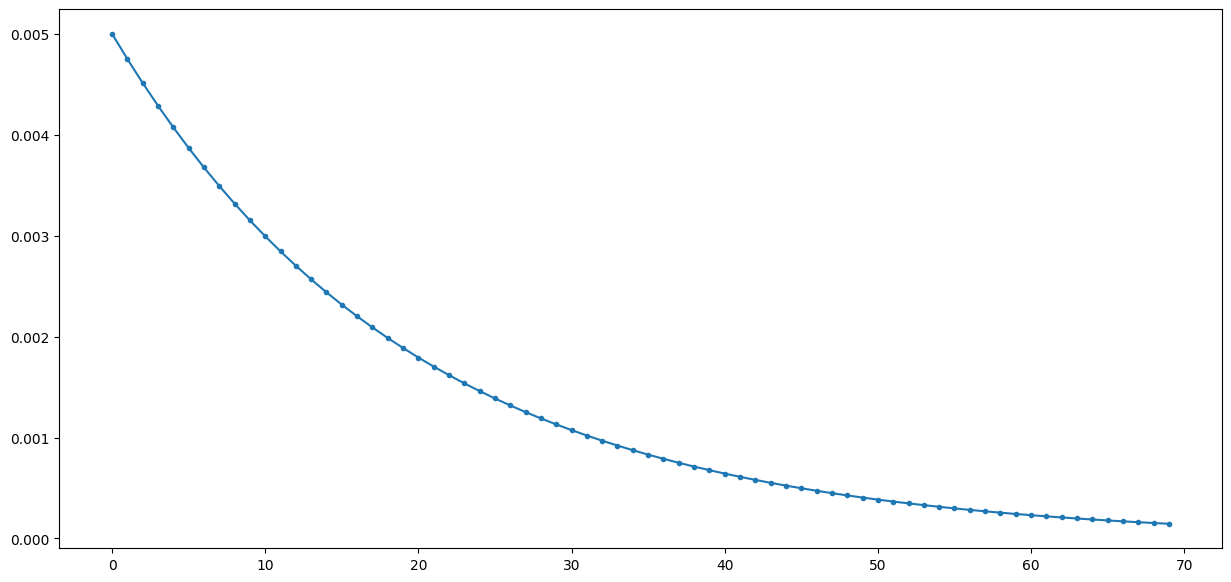

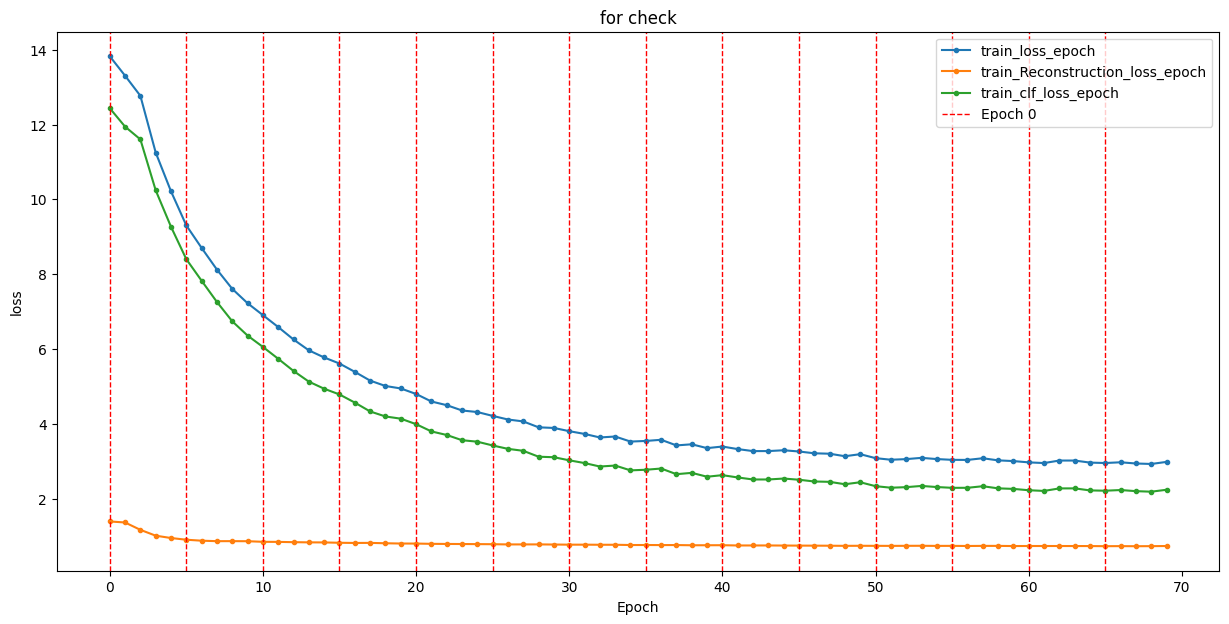

2024-05-10 10:48:41,631 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:48:41,644 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1715356097.GPU2.2482759.0 
2024-05-10 10:48:41,825 INFO - utils.utils_Dandan_plot - Finish save images at: /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/trainingLoss_train_Reconstruction_loss_epoch_.png 


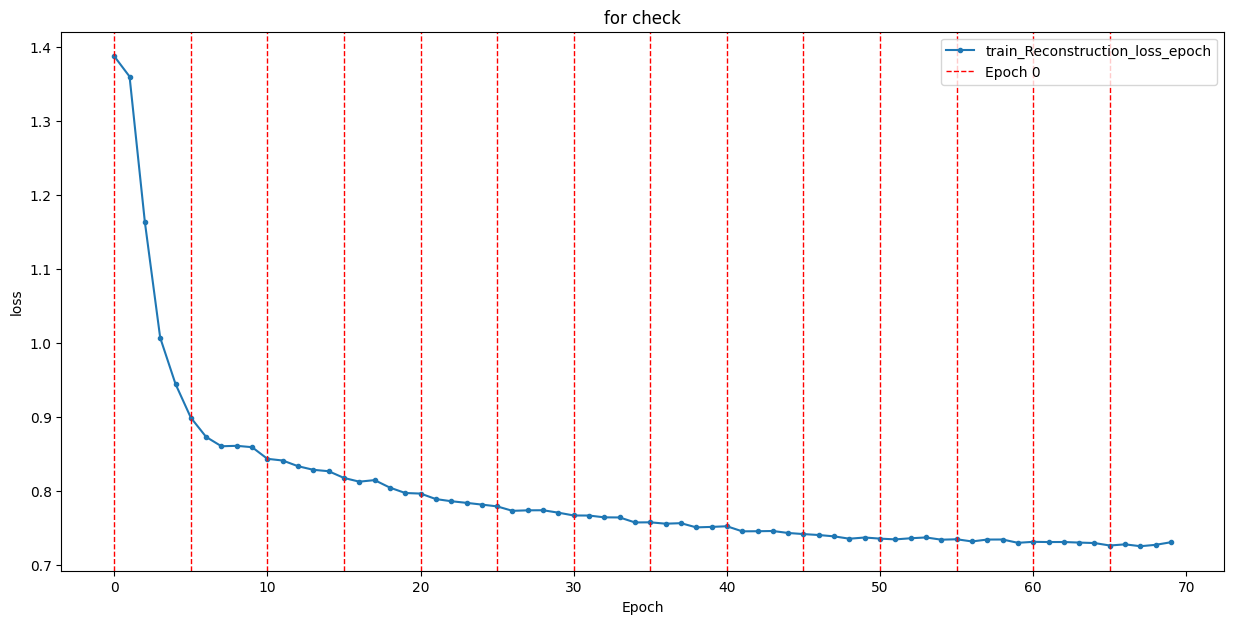

2024-05-10 10:48:42,006 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:48:42,016 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1715356097.GPU2.2482759.0 
... storing 'dataset_label' as categorical
... storing 'cell_type' as categorical
... storing 'day' as categorical
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap

<Figure size 1500x700 with 0 Axes>

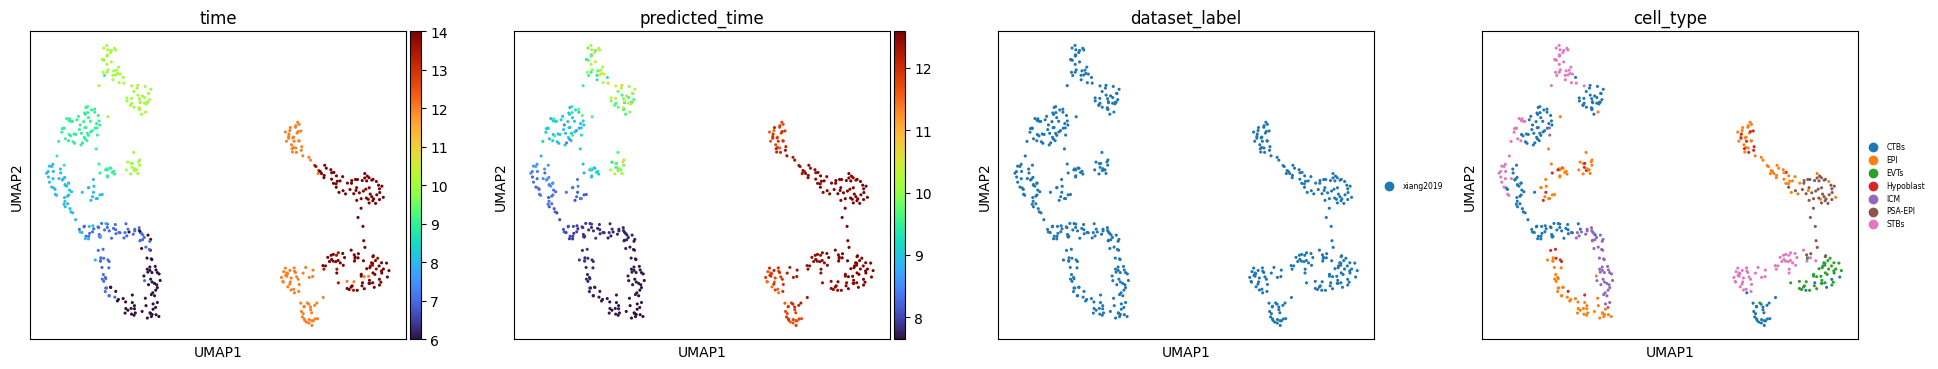

figure save as /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50//n50_latentSpace_umap_byScanpy.png


In [5]:
#  ---------------------------------------------- TASK: use all data to train a model  ----------------------------------------------
if args.train_whole_model:
    drop_out_donor = "t"
    print(f"drop the donor: {drop_out_donor}")
    cell_drop_index_list = cell_time.loc[cell_time["dataset_label"] == drop_out_donor].index
    sc_expression_df_filter = sc_expression_df.drop(cell_drop_index_list, axis=0)
    cell_time_filter = cell_time.drop(cell_drop_index_list, axis=0)
    cell_time_filter = cell_time_filter.loc[sc_expression_df_filter.index]
    sc_expression_train, y_time_nor_train, donor_index_train, runner, experiment, _m, train_clf_result, label_dic, total_result = onlyTrain_model(
        sc_expression_df_filter, donor_dic,
        special_path_str,
        cell_time_filter,
        time_standard_type, config, args,
        device=device, plot_latentSpaceUmap=False, plot_trainingLossLine=True, time_saved_asFloat=True, batch_dic=batch_dic, donor_str="day",
        batch_size=int(args.batch_size))  # 2023-10-24 17:44:31 batch as 10,000 due to overfit, batch size as 100,000 may be have different result
    predict_donors_df = pd.DataFrame(train_clf_result, columns=["pseudotime"], index=cell_time_filter.index)
    predict_donors_df['predicted_time'] = predict_donors_df['pseudotime'].apply(denormalize, args=(min(label_dic.keys()) / 100, max(label_dic.keys()) / 100,
                                                                                                   min(label_dic.values()), max(label_dic.values())))
    cell_time_filter = pd.concat([cell_time_filter, predict_donors_df], axis=1)

    plt_image_adata = ad.AnnData(X=total_result["mu"].cpu().numpy())
    plt_image_adata.obs = cell_time_filter[["time", "predicted_time", "dataset_label", "cell_type", "day"]]

    plt_umap_byScanpy(plt_image_adata.copy(), ["time", "predicted_time", "dataset_label", "cell_type"], save_path=save_file_name, mode=None, figure_size=(5, 4),
                      color_map="turbo",
                      n_neighbors=50, n_pcs=20, special_file_name_str="n50_")  # color_map="viridis"

2024-05-10 10:48:50,197 INFO - __main__ - start task: k-fold test with ['day10.0', 'day12.0', 'day13.5', 'day14.0', 'day6.0', 'day7.0', 'day8.0', 'day9.0']. 
2024-05-10 10:48:50,198 INFO - utils.utils_DandanProject - the 1/8 fold train, use donor-day10.0 as test set 
2024-05-10 10:48:50,216 INFO - utils.utils_DandanProject - Set x_sc_train data with shape (gene, cells): torch.Size([945, 478]) 
2024-05-10 10:48:50,217 INFO - utils.utils_DandanProject - Set x_sc_test data with shape (gene, cells): torch.Size([945, 77]) 
2024-05-10 10:48:50,260 INFO - utils.utils_DandanProject - label dictionary: {600: -5.0, 700: -3.75, 800: -2.5, 900: -1.25, 1200: 2.5, 1350: 4.375, 1400: 5.0, 1000: 0.0} 
2024-05-10 10:48:50,261 INFO - utils.utils_DandanProject - Normalize train y_time_nor_train type: embryoneg5to5, with y_time_nor_train lable: [ 600.  700.  800.  900. 1200. 1350. 1400.], shape: torch.Size([478]), 
detail: [-5.    -3.75  -2.5   -1.25   2.5    4.375  5.   ] 
2024-05-10 10:48:50,262 INFO - 

Free Memory Percentage: 30.60%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.135GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.135GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

2024-05-10 10:49:05,969 INFO - utils.utils_DandanProject - this epoch final, on test data:[{'test_loss_epoch': 3.2798867225646973, 'test_Reconstruction_loss_epoch': 0.6825385689735413, 'test_KLD_epoch': -11.812204360961914, 'test_clf_loss_epoch': 2.594395160675049}] 
2024-05-10 10:49:05,974 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, predict_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:49:06,022 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:49:06,058 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-10 10:49:06,058 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-10 10:49:06,059 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:49:06,075 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day10.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356130.GPU2.2482759.1 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day10.0/SuperviseVanillaVAE_regressionClfDecoder_mous

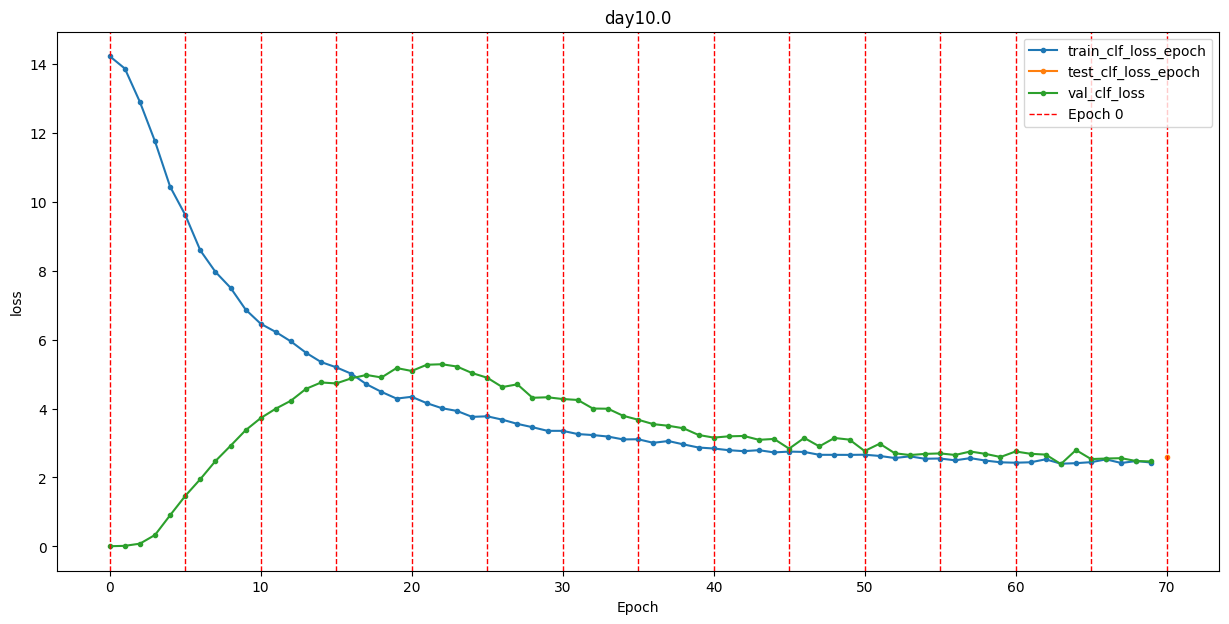

2024-05-10 10:49:06,511 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:49:06,527 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day10.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356130.GPU2.2482759.1 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day10.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356145.GPU2.2482759.2 
2024-05-10 10:49:06,529 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEm

Free Memory Percentage: 30.58%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.135GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.135GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2024-05-10 10:49:25,530 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:49:25,564 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-10 10:49:25,565 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-10 10:49:25,566 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:49:25,581 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day12.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356146.GPU2.2482759.3 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day12.0/SuperviseVanillaVAE_regressionClfDecoder_mous

<Figure size 1500x700 with 0 Axes>

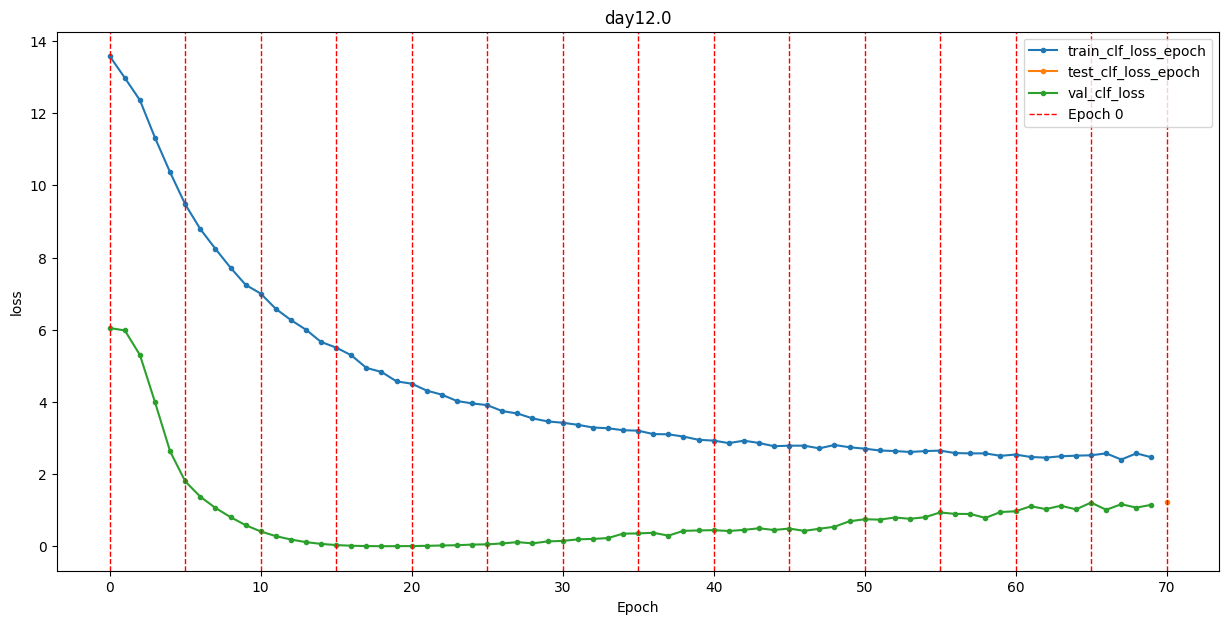

2024-05-10 10:49:26,008 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:49:26,031 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day12.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356146.GPU2.2482759.3 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day12.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356165.GPU2.2482759.4 
2024-05-10 10:49:26,046 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEm

Free Memory Percentage: 30.55%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.133GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.133GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2024-05-10 10:49:47,256 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:49:47,292 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-10 10:49:47,292 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-10 10:49:47,293 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:49:47,308 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day13.5/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356166.GPU2.2482759.5 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day13.5/SuperviseVanillaVAE_regressionClfDecoder_mous

<Figure size 1500x700 with 0 Axes>

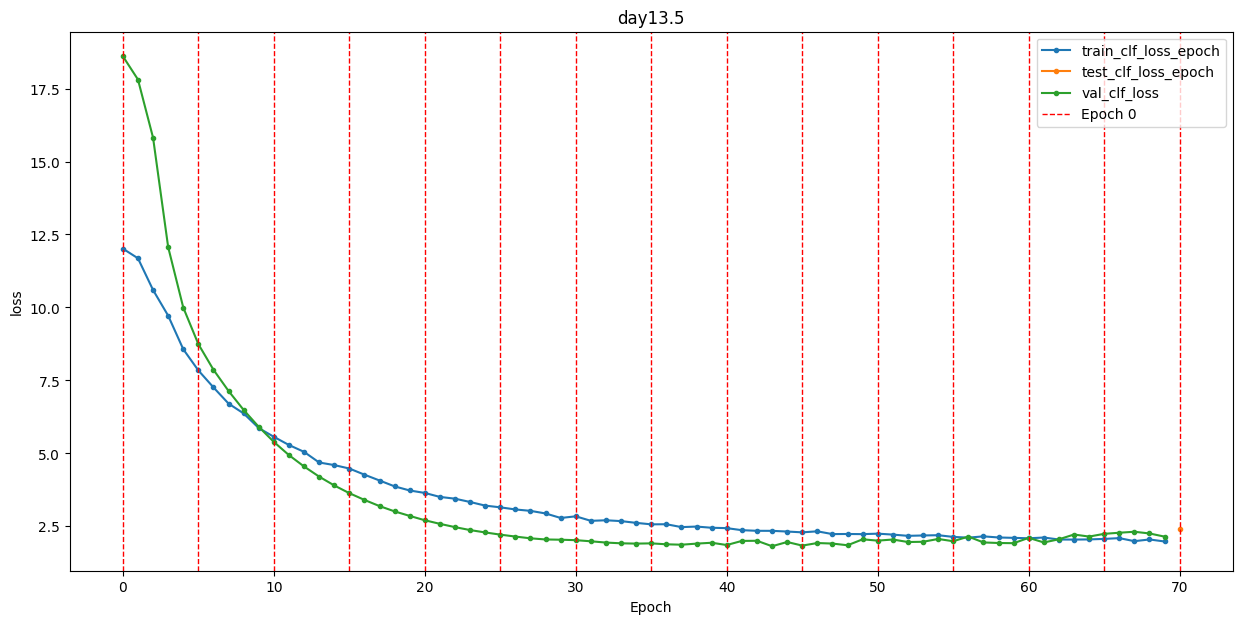

2024-05-10 10:49:47,742 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:49:47,757 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day13.5/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356166.GPU2.2482759.5 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day13.5/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356187.GPU2.2482759.6 
2024-05-10 10:49:47,759 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEm

Free Memory Percentage: 30.56%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.133GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.133GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2024-05-10 10:50:10,033 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:50:10,067 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-10 10:50:10,067 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-10 10:50:10,068 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:50:10,083 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day14.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356187.GPU2.2482759.7 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day14.0/SuperviseVanillaVAE_regressionClfDecoder_mous

<Figure size 1500x700 with 0 Axes>

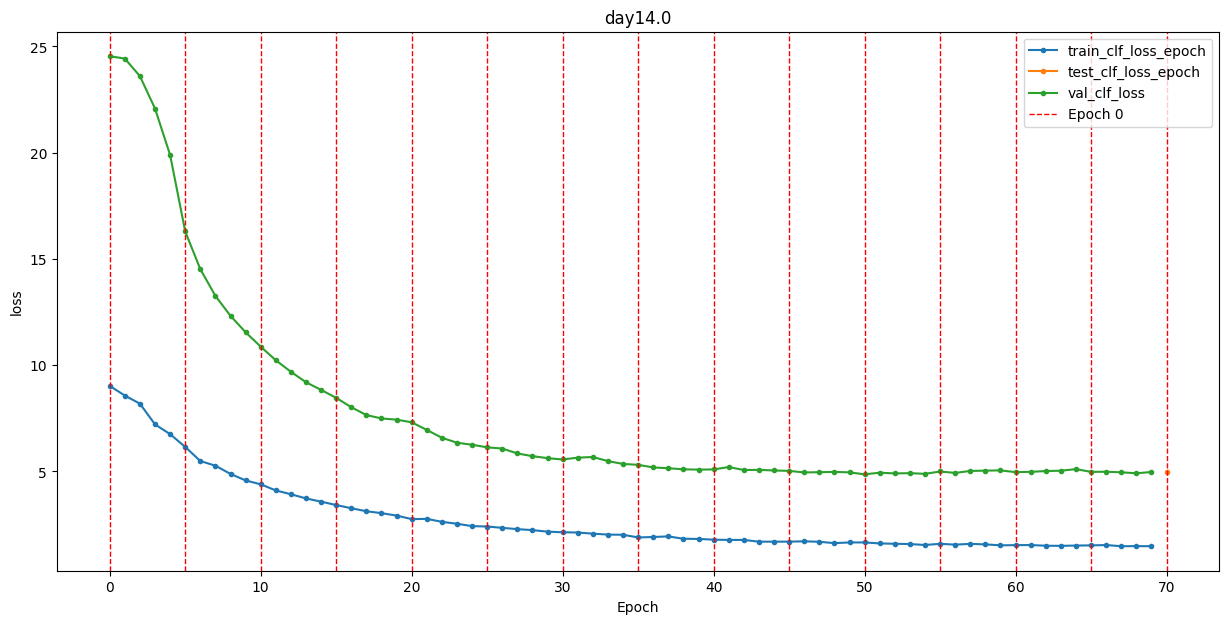

2024-05-10 10:50:10,490 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:50:10,505 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day14.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356187.GPU2.2482759.7 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day14.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356209.GPU2.2482759.8 
2024-05-10 10:50:10,506 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEm

Free Memory Percentage: 30.55%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.133GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.133GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2024-05-10 10:50:36,502 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:50:36,535 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-10 10:50:36,536 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-10 10:50:36,537 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:50:36,552 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day6.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356210.GPU2.2482759.9 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day6.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_

<Figure size 1500x700 with 0 Axes>

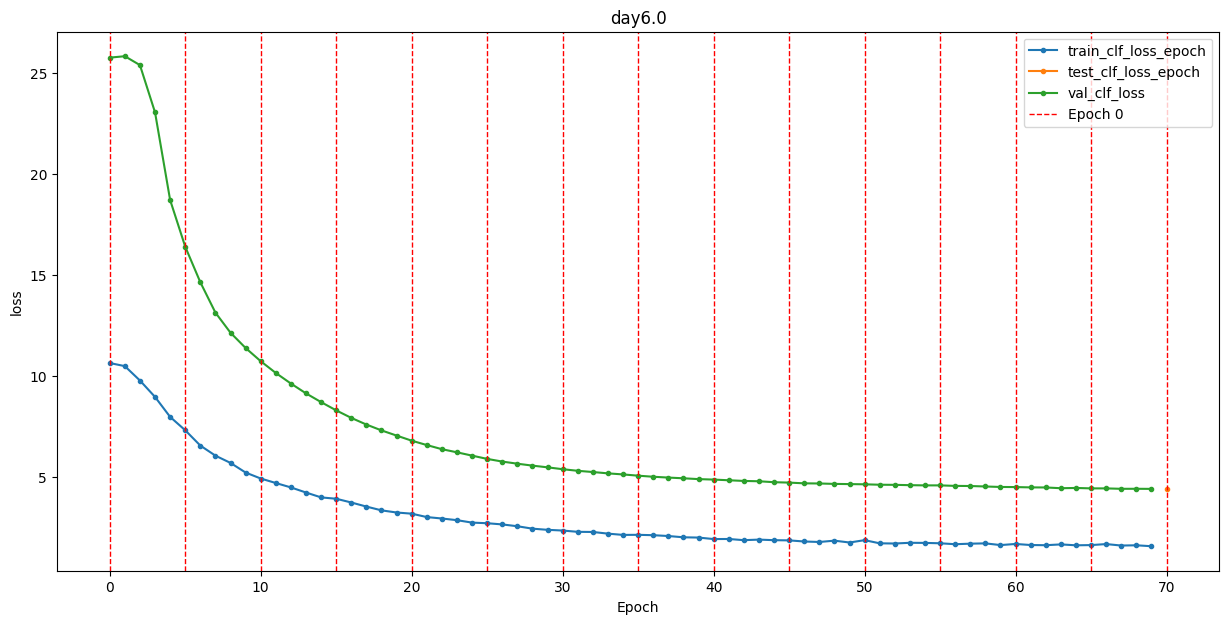

2024-05-10 10:50:36,967 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:50:36,983 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day6.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356210.GPU2.2482759.9 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day6.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356236.GPU2.2482759.10 
2024-05-10 10:50:36,984 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmb

Free Memory Percentage: 30.53%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.133GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.133GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2024-05-10 10:50:55,601 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:50:55,634 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-10 10:50:55,634 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-10 10:50:55,635 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:50:55,650 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day7.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356237.GPU2.2482759.11 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day7.0/SuperviseVanillaVAE_regressionClfDecoder_mouse

<Figure size 1500x700 with 0 Axes>

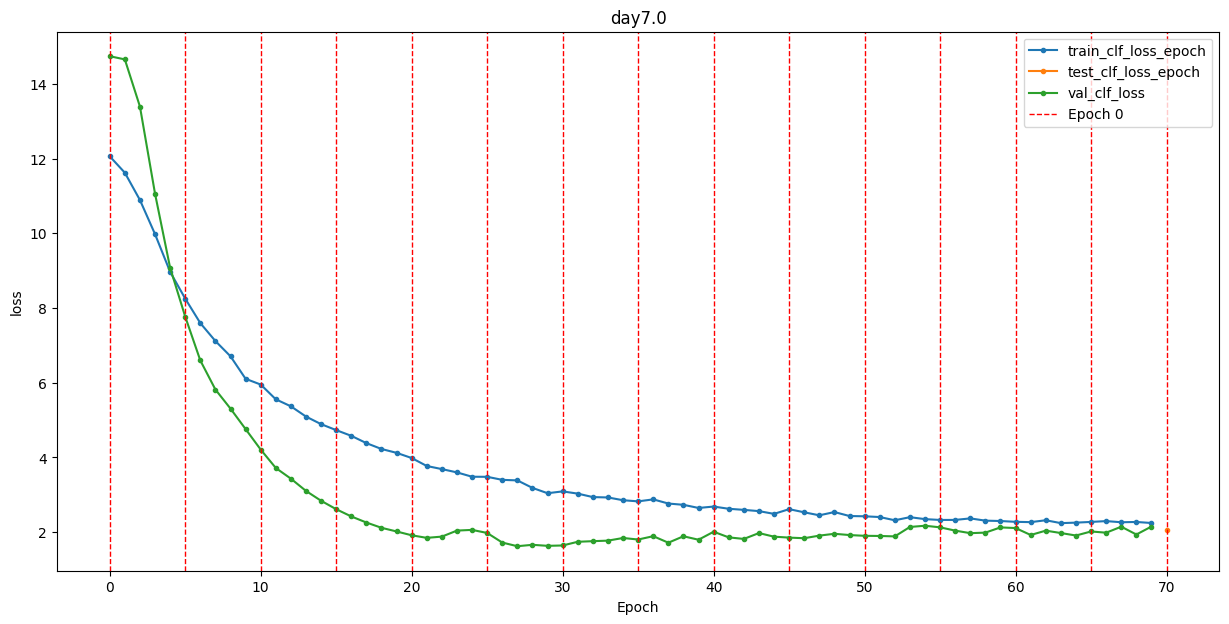

2024-05-10 10:50:56,071 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:50:56,086 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day7.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356237.GPU2.2482759.11 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day7.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356255.GPU2.2482759.12 
2024-05-10 10:50:56,087 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEm

Free Memory Percentage: 30.53%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.133GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.133GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2024-05-10 10:51:13,981 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:51:14,014 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-10 10:51:14,014 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-10 10:51:14,015 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:51:14,031 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day8.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356256.GPU2.2482759.13 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day8.0/SuperviseVanillaVAE_regressionClfDecoder_mouse

<Figure size 1500x700 with 0 Axes>

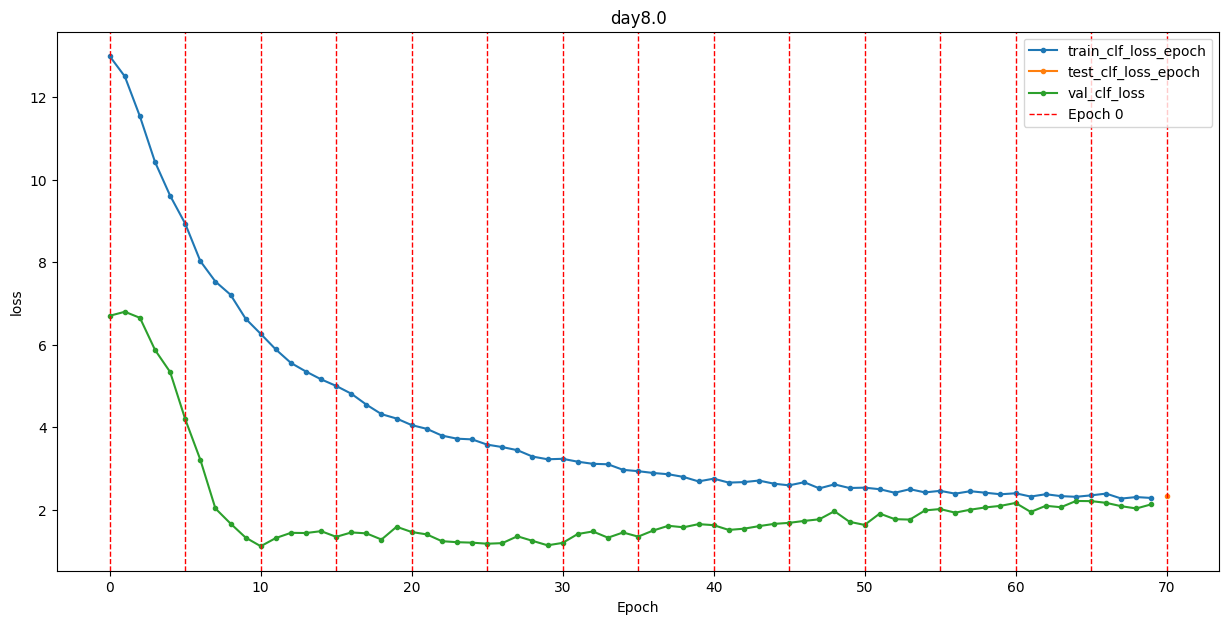

2024-05-10 10:51:14,442 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:51:14,461 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day8.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356256.GPU2.2482759.13 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day8.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356273.GPU2.2482759.14 
2024-05-10 10:51:14,462 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEm

Free Memory Percentage: 30.53%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 3.783GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 37.131GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 37.131GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Predicting: 0it [00:00, ?it/s]

2024-05-10 10:51:31,813 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-10 10:51:31,847 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-10 10:51:31,848 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-10 10:51:31,849 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-10 10:51:31,864 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day9.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356274.GPU2.2482759.15 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day9.0/SuperviseVanillaVAE_regressionClfDecoder_mouse

<Figure size 1500x700 with 0 Axes>

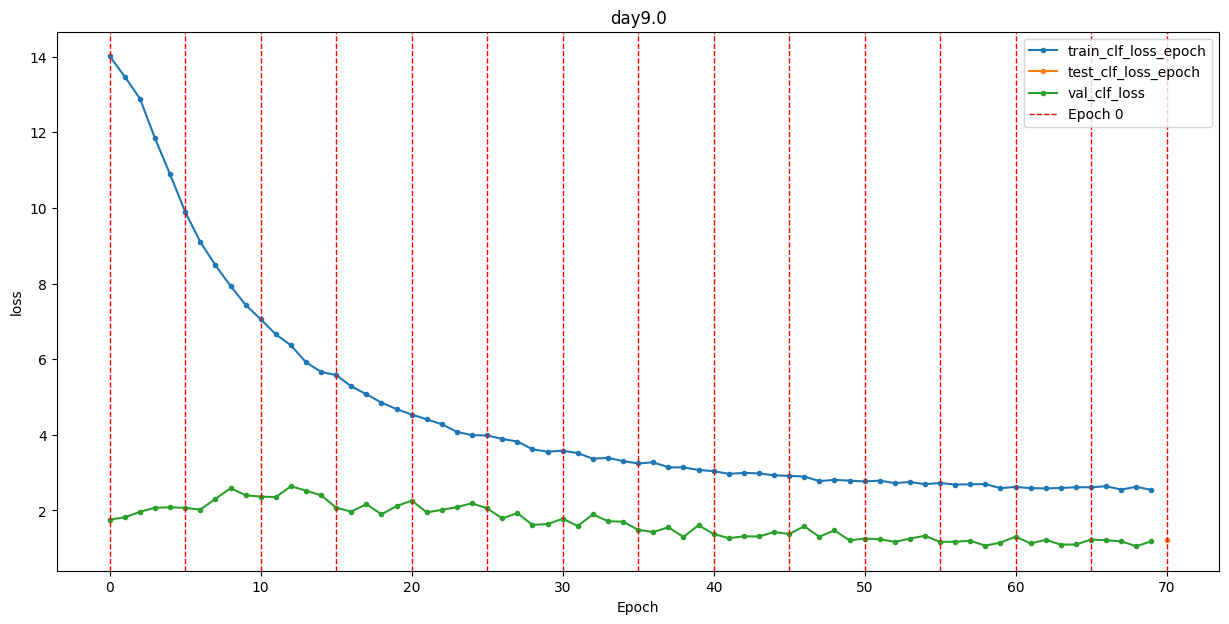

2024-05-10 10:51:32,285 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-10 10:51:32,305 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day9.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356274.GPU2.2482759.15 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/day9.0/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_2/events.out.tfevents.1715356291.GPU2.2482759.16 
2024-05-10 10:51:32,307 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEm

=== data correlation: 
Spearman correlation=0.91631, p-value=0.00000; 
Pearson correlation=0.91689, p-value=0.00000; 
Kendall correlation=0.77398, p-value=0.00000; 
R-squared=0.49243.


<Figure size 1500x700 with 0 Axes>

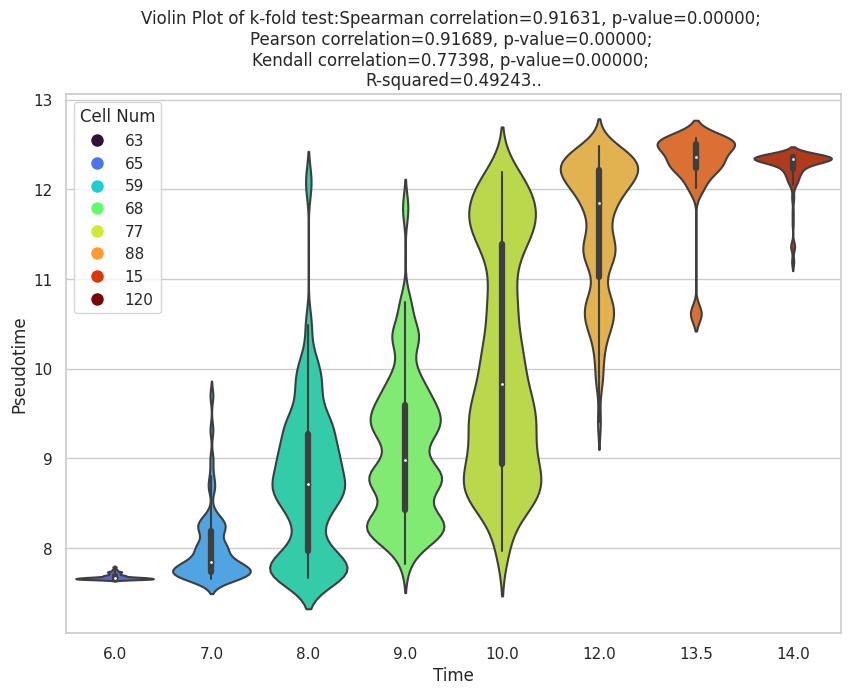

2024-05-10 10:51:33,209 INFO - __main__ - Finish plot image and fold-test. 
2024-05-10 10:51:33,209 INFO - __main__ - Finish fold-test. 
2024-05-10 10:51:33,210 INFO - __main__ - Finish all. 


Save at /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/240505_humanEmbryo_xiang2019/240322Human_embryo/xiang2019/hvg500/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch70_minGeneNum50/violine.png


In [6]:
## # # ----------------------------------TASK 1: K-FOLD TEST--------------------------------------
if args.kfold_test:
    predict_donors_dic, label_dic = task_kFoldTest(donor_list, sc_expression_df, donor_dic, batch_dic, special_path_str, cell_time, time_standard_type,
                                                   config, args.train_epoch_num, _logger, donor_str="day", batch_size=args.batch_size, cmap_color="turbo")

    _logger.info("Finish fold-test.")

_logger.info("Finish all.")


